# 07 · Multilingual ASR with OpenEnv

Listen to a Kannada clip, score a transcript against the environment, and compare what Gemma 4
wrote before and after GRPO, all on a CPU against the
[hosted Space](https://huggingface.co/spaces/FineEnvs/fleurs-asr-env). The last two sections run
the trained adapter and launch training, which need a GPU or HF Jobs.

Start from the project folder:

```bash
cd 07-multilingual-asr
uv run --frozen --project envs/multilingual_asr --with jupyterlab --with matplotlib jupyter lab
```

In [1]:
import requests
from IPython.display import Audio, display
from multilingual_asr.client import connect
from multilingual_asr.models import AsrAction

URL = "https://fineenvs-fleurs-asr-env.hf.space"

/Users/adithya/projects/FineEnvs-workspace/FineEnvs-worktrees/multilingual-asr/07-multilingual-asr/envs/multilingual_asr/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## What the environment serves

The manifest says what this server holds: the corpus snapshot, the splits, the frozen evaluation
sets, and how answers are graded.

In [2]:
with connect(URL) as client:
    manifest = client.manifest()

counts = manifest["counts"]
print(f"{sum(c['tasks'] for c in counts):,} tasks across {len({c['language'] for c in counts})} languages")
print("splits:", manifest["splits"])
print("evaluation sets:", {name: s["tasks"] for name, s in manifest["eval_splits"].items()})
print("grading:", manifest["grading"]["policy"], "|", manifest["grading"]["reward"])

1,151,940 tasks across 102 languages
splits: ['train', 'validation', 'test', 'eval_102_test', 'eval_102_validation', 'eval_1_test', 'eval_1_validation', 'eval_21_test', 'eval_21_validation']
evaluation sets: {'eval_102_test': 1836, 'eval_102_validation': 1836, 'eval_1_test': 838, 'eval_1_validation': 200, 'eval_21_test': 1050, 'eval_21_validation': 1050}
grading: fleurs-asr-error-rate-v1 | 0.8 * max(0, 1 - error_rate) + 0.2 * exact_match


## A held-out Kannada clip

`eval_1_test` is every Kannada test clip in FLEURS, 838 of them. The observation carries the
prompt and a link to the audio, never the reference.

In [3]:
with connect(URL) as client:
    row = client.get_task_range("eval_1_test", 41, 42)[0]
    observation = client.reset(task_id=row["task_id"]).observation

print(observation.task_id)
print(f"{observation.language_name} · {observation.duration_seconds:.1f} s · scored by {observation.error_unit}")
print(observation.prompt)
display(Audio(url=f"{URL}/assets/{observation.asset_sha256}?task_id={observation.task_id}"))

fleurs-kn_in.test.1672168baabf9e98a561cb67f732d8420aca1c2432dcb507dab38901d9bf3752
Kannada · 6.9 s · scored by wer
Transcribe this Kannada speech. Return only the transcription, in Kannada, lowercased and without punctuation.


## Score an answer

`step` grades a transcript and ends the episode. The reward is `0.8 × (1 − error rate) + 0.2 × exact
match`; for Kannada the deployed Space counts words, and both error rates come back in the metrics.
An empty answer scores zero.

In [4]:
def score(transcript):
    with connect(URL) as client:
        client.reset(task_id=row["task_id"])
        result = client.step(AsrAction(transcript=transcript))
    return result.reward, result.observation.metrics

print(score(""))

(0.0, {'wer': 1.0, 'cer': 1.0, 'exact_match': False, 'reference_units': 12.0, 'predicted_units': 0.0})


## Before and after training

Every held-out prediction from the Kannada run is in
[FineEnvs/multilingual-multimodal-rl-runs](https://huggingface.co/datasets/FineEnvs/multilingual-multimodal-rl-runs).
Here is what the untuned model and the final checkpoint wrote for this clip, scored live by the
same server.

In [5]:
import pyarrow.parquet as pq
from huggingface_hub import hf_hub_download

evals = pq.read_table(hf_hub_download(
    "FineEnvs/multilingual-multimodal-rl-runs", "data/asr_kannada_evals.parquet", repo_type="dataset"
)).to_pylist()
this_clip = {r["checkpoint"]: r for r in evals if r["task_id"] == row["task_id"]}

print("reference:", this_clip["base"]["reference"], "\n")
for name in ("base", "step-575"):
    reward, metrics = score(this_clip[name]["prediction"])
    print(f"{name:>8}  reward {reward:.3f}  CER {metrics['cer']:.3f}  WER {metrics['wer']:.3f}")
    print("         ", this_clip[name]["prediction"], "\n")

reference: ಮನೆಗೆ ಹಿಂದಿರುಗುವ ಪ್ರಯಾಣಿಕರಿಗೆ ತಾಳ್ಮೆ ಮತ್ತು ತಿಳುವಳಿಕೆ ಸಹ ಅಗತ್ಯ ಎಂದು ಜನರು ನಿರೀಕ್ಷಿಸದೆ ಇರಬಹುದು 



    base  reward 0.533  CER 0.165  WER 0.333
          ಮನೆಗೆ ಹಿಂದಿರುಗ ಪ್ರಾಯಾಣಿಕರಿಗೆ ತಾಳ್ಮೆ ಮತ್ತು ತಿಳುವಳಿಕೆ ಸಹ ಅಗತ್ಯ ಎಂದು ಜನರು ನಿರ್િક્ષಿಸುತ್ತಿರುವುದು 



step-575  reward 0.600  CER 0.033  WER 0.250
          ಮನೆಗೆ ಹಿಂದಿರುಗ ಪ್ರ ಯಾಣಿಕರಿಗೆ ತಾಳ್ಮೆ ಮತ್ತು ತಿಳುವಳಿಕೆ ಸಹ ಅಗತ್ಯ ಎಂದು ಜನರು ನಿರೀಕ್ಷಿಸದೆ ಇರಬಹುದು 



## The whole run

The same dataset has each checkpoint's average over all 838 clips, and its change from the untuned
model, paired clip by clip, with a 95% interval.

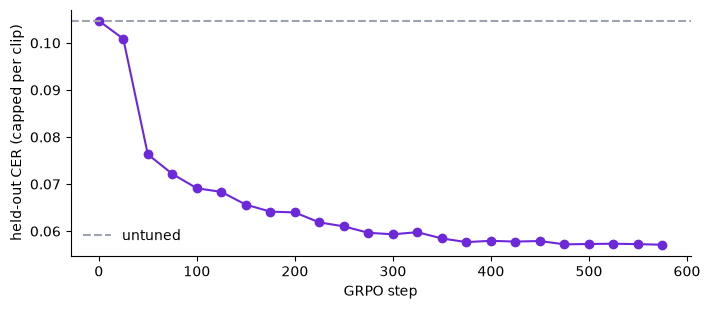

step 0: 0.1047   step 575: 0.0571   change -0.0476 (-0.0567, -0.0385)


In [6]:
import matplotlib.pyplot as plt

curves = pq.read_table(hf_hub_download(
    "FineEnvs/multilingual-multimodal-rl-runs", "data/curves.parquet", repo_type="dataset"
)).to_pylist()
asr = sorted((c for c in curves if c["run"] == "asr-kannada"), key=lambda c: c["step"])

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot([c["step"] for c in asr], [c["cer"] for c in asr], marker="o", color="#6d28d9")
ax.axhline(asr[0]["cer"], ls="--", color="#9ca3af", label="untuned")
ax.set_xlabel("GRPO step")
ax.set_ylabel("held-out CER (capped per clip)")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.show()
print(f"step 0: {asr[0]['cer']:.4f}   step {asr[-1]['step']}: {asr[-1]['cer']:.4f}   "
      f"change {asr[-1]['cer_change']:+.4f} ({asr[-1]['cer_low']:+.4f}, {asr[-1]['cer_high']:+.4f})")

## Run the trained adapter (GPU)

[FineEnvs/gemma-4-E4B-it-kannada-asr-grpo](https://huggingface.co/FineEnvs/gemma-4-E4B-it-kannada-asr-grpo)
is a LoRA adapter over `google/gemma-4-E4B-it`. This transcribes the clip above with it. It needs a
GPU with about 20 GB and the project's `train` extra.

In [7]:
RUN_ON_GPU = False

if RUN_ON_GPU:
    import io

    import soundfile as sf
    import torch
    from peft import PeftModel
    from transformers import AutoProcessor, Gemma4ForConditionalGeneration

    processor = AutoProcessor.from_pretrained("google/gemma-4-E4B-it")
    model = Gemma4ForConditionalGeneration.from_pretrained(
        "google/gemma-4-E4B-it", dtype=torch.bfloat16, device_map="auto")
    model = PeftModel.from_pretrained(model, "FineEnvs/gemma-4-E4B-it-kannada-asr-grpo")

    wav = requests.get(f"{URL}/assets/{observation.asset_sha256}",
                       params={"task_id": observation.task_id}, timeout=120).content
    audio, _ = sf.read(io.BytesIO(wav), dtype="float32")
    inputs = processor.apply_chat_template([{"role": "user", "content": [
        {"type": "audio", "audio": audio}, {"type": "text", "text": observation.prompt}]}],
        add_generation_prompt=True, tokenize=True, return_dict=True, return_tensors="pt").to(model.device)
    output = model.generate(**inputs, max_new_tokens=448, do_sample=False)
    transcript = processor.batch_decode(output[:, inputs["input_ids"].shape[1]:], skip_special_tokens=True)[0]
    print(transcript, score(transcript))

## Train

The run behind the model is two HF Jobs: one trains on every Kannada clip, the other scores each
checkpoint on the 838 test clips as it is saved. Both commands are in
[`train/README.md`](../train/README.md). On a local GPU, a four-step check of the whole loop:

```bash
uv run --frozen --project envs/multilingual_asr --extra train python train/grpo_asr.py \
  --corpus data/corpus-manifest.json --languages kn_in --families transcription \
  --eval-split eval_1_validation --eval-limit 8 --num-generations 8 --max-steps 4 --smoke
```